# Step 1: Dataset Loading & Exploratory Data Analysis

## 1.1  Load & Inspect the Dataset

In [4]:
# Load CC_GENERAL.csv. Print .shape, .info(), and .head(10).

import pandas as pd
import numpy as np

df = pd.read_csv("CC GENERAL.csv")

df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [2]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8950, 18)


In [3]:
print("Dataset Info:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
# Drop the CUST_ID column (unique identifier, not a feature).
df = df.drop("CUST_ID", axis=1)

print("Updated Shape:", df.shape)

Updated Shape: (8950, 17)


CUST_ID is a unique identifier and does not contribute to clustering, so it was removed.

In [8]:
#  Report how many missing values exist in each column.
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [10]:
# Impute missing CREDIT_LIMIT with the column median, and missing MINIMUM_PAYMENTS with the column median. Report how many values were imputed.
credit_limit_missing = df["CREDIT_LIMIT"].isnull().sum()
minimum_payment_missing = df["MINIMUM_PAYMENTS"].isnull().sum()

df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

print("CREDIT_LIMIT values imputed :", credit_limit_missing)
print("MINIMUM_PAYMENTS values imputed :", minimum_payment_missing)

CREDIT_LIMIT values imputed : 0
MINIMUM_PAYMENTS values imputed : 0


In [12]:
print(df.isnull().sum())

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


Missing values were replaced with the median because it is robust to outliers and preserves the data distribution.

In [ ]:
# Check for and report duplicate rows.
duplicate_rows = df.duplicated().sum()


print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


## 1.2  Univariate Analysis

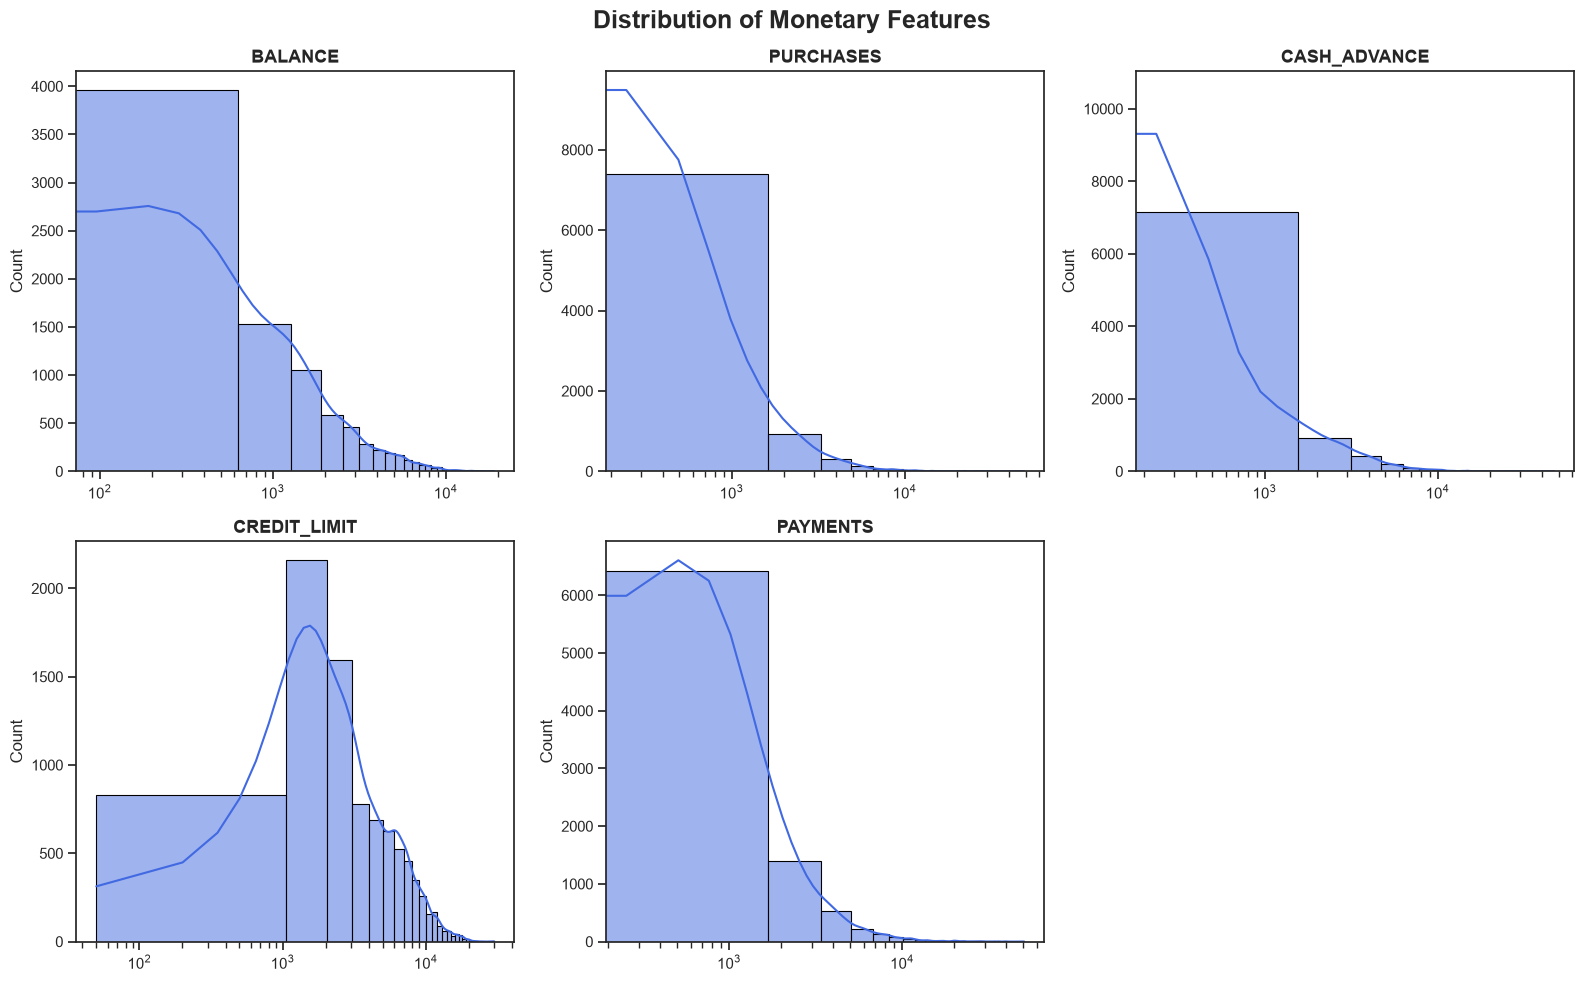

In [20]:
# Plot histograms for: BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS (log-scale the x-axis for readability).

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i],
        color="royalblue",
        edgecolor="black"
    )

    axes[i].set_xscale("log")
    axes[i].set_title(col, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Remove empty subplot
fig.delaxes(axes[-1])

plt.suptitle("Distribution of Monetary Features", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

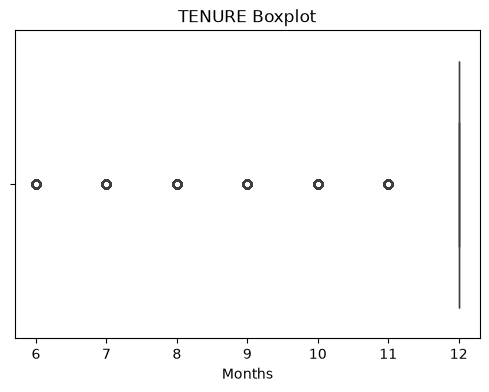

In [15]:
# Plot a boxplot of TENURE (months as a cardholder) to see how long customers have held their cards.

plt.figure(figsize=(6,4))

sns.boxplot(x=df["TENURE"])

plt.title("TENURE Boxplot")
plt.xlabel("Months")

plt.show()

Most customers have held their credit cards for a similar duration, with only a few extreme values.

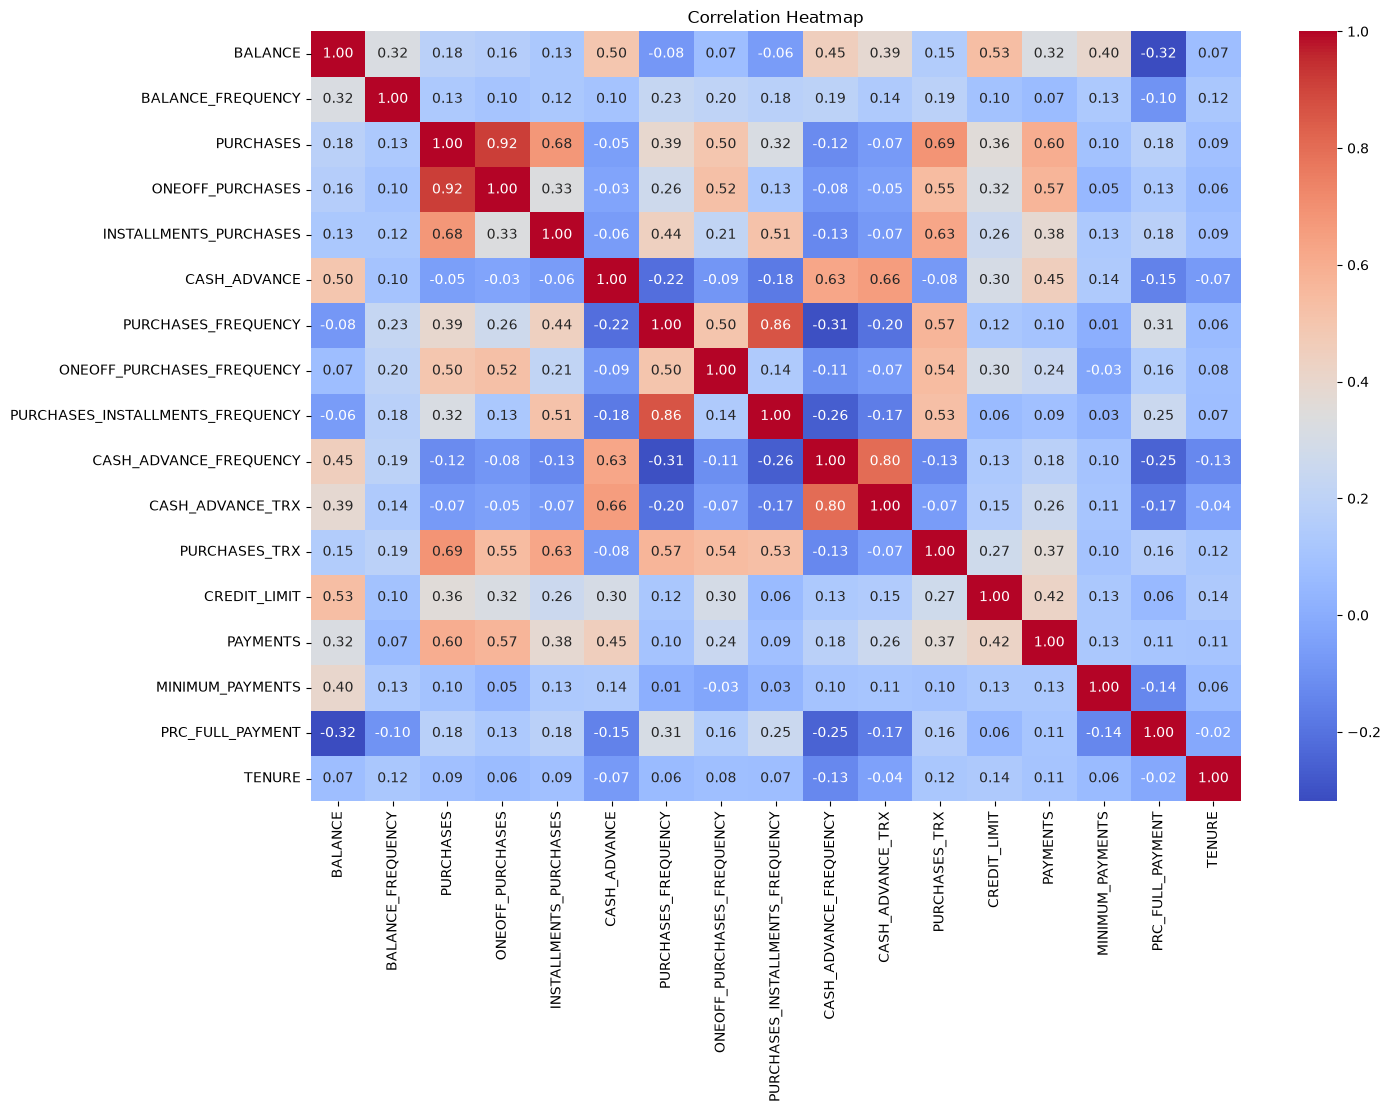

In [16]:
# Plot a correlation heatmap of all 17 numeric features. Which features are highly correlated?

plt.figure(figsize=(15,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

## 1.3  Customer-Level Analysis

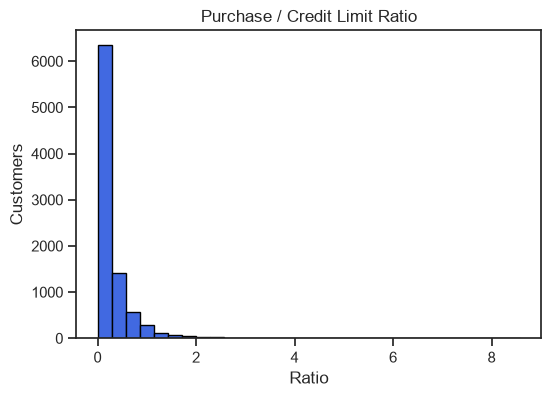

In [23]:
# Compute the ratio PURCHASES / CREDIT_LIMIT for each customer as a rough utilisation measure. Plot its distribution.
df["Purchase_Credit_Ratio"] = df["PURCHASES"] / (df["CREDIT_LIMIT"] + 1)

plt.figure(figsize=(6,4))

plt.hist(df["Purchase_Credit_Ratio"],
         bins=30,
         color="royalblue",
         edgecolor="black")

plt.title("Purchase / Credit Limit Ratio")

plt.xlabel("Ratio")

plt.ylabel("Customers")

plt.show()

Most customers use only a small portion of their available credit limit for purchases.

In [24]:
#  Who are the top 10 customers by CASH_ADVANCE? Are they also high PURCHASES customers, or a distinct group?
top10 = df.sort_values(by="CASH_ADVANCE", ascending=False).head(10)

top10[["CASH_ADVANCE","PURCHASES"]]

,CASH_ADVANCE,PURCHASES
2159,47137.21176,431.93
1059,29282.10915,3719.00
71,27296.48576,4523.27
7254,26268.69989,1750.66
7645,26194.04954,0.00
2454,23130.82106,0.00
883,22665.77850,0.00
6371,21943.84942,0.00
3806,20712.67008,4995.80
6455,20277.33112,1490.75


These customers have the highest cash advances. Compare their PURCHASES values to determine whether they are also high-spending customers or belong to a different customer group.

In [25]:
# Report: what % of customers have never made a purchase (PURCHASES == 0)?

never_purchase = (df["PURCHASES"] == 0).sum()

percentage = (never_purchase / len(df)) * 100

print("Customers with PURCHASES = 0 :", never_purchase)
print(f"Percentage : {percentage:.2f}%")

Customers with PURCHASES = 0 : 2044
Percentage : 22.84%


This shows the percentage of customers who have never used their credit card for purchases.

In [26]:
purchase_sorted = df["PURCHASES"].sort_values(ascending=False)

cumulative = purchase_sorted.cumsum()

total_purchase = purchase_sorted.sum()

percentage_purchase = cumulative / total_purchase

customers_needed = (percentage_purchase <= 0.80).sum()

customer_percent = (customers_needed / len(df)) * 100

print(f"{customer_percent:.2f}% of customers contribute nearly 80% of total purchases.")

26.20% of customers contribute nearly 80% of total purchases.


This analysis checks whether a small percentage of customers contribute to most of the purchase volume, following the Pareto (80–20) principle.

# Step 2: Feature Engineering & Preprocessing

## 2.1  Engineer Behavioural Features

In [ ]:
# Monthly_Avg_Purchase: PURCHASES / TENURE

In [ ]:
# Monthly_Avg_Cash_Advance: CASH_ADVANCE / TENURE. 

In [ ]:
# Limit_Usage: BALANCE / CREDIT_LIMIT (guard against divide-by-zero).


In [ ]:
#  Payment_to_Minpayment_Ratio: PAYMENTS / (MINIMUM_PAYMENTS + 1).


In [ ]:
# Print the resulting feature-engineered DataFrame — one row per customer — and .describe() on the new columns. Note the range and skewness of each.


## 2.2  Handle Outliers

In [ ]:
# Plot boxplots for BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, and PAYMENTS. Identify extreme outliers.

In [ ]:
# Cap outliers using the IQR method: for each column, cap values above Q3 + 3×IQR to that threshold (winsorization — do not drop rows).

In [ ]:
# Re-plot boxplots after capping to confirm outliers are handled.

## 2.3  Transform Skewed Features

In [ ]:
# Plot histograms of BALANCE, PURCHASES, CASH_ADVANCE, and CREDIT_LIMIT before transformation.

In [ ]:
# Apply log1p transformation to all monetary columns (they are typically right-skewed).


In [ ]:
# Re-plot histograms after transformation. Are the distributions more symmetrical?

## 2.4  Scale the Features

In [ ]:
# Apply StandardScaler to the full set of engineered + transformed features.

In [ ]:
# Store the scaled features as cc_scaled (a numpy array or DataFrame).

In [ ]:
# Optionally apply PCA (retain 90–95% variance) to reduce dimensionality before clustering; report how many components were kept.

In [ ]:
# Print the mean and standard deviation of each scaled feature to confirm scaling worked (mean ≈ 0, std ≈ 1).

# Step 3: K-Means Clustering

## 3.1  Elbow Method — Find Optimal k

In [ ]:
# Run KMeans for k = 2, 3, 4, 5, 6, 7, 8, 9, 10 (use init='k-means++', n_init=10, random_state=42).

In [ ]:
# For each k, compute and store: Within-Cluster Sum of Squares (inertia_).

In [ ]:
# Plot the Elbow Curve (k vs Inertia). Mark the elbow point visually.

In [ ]:
# Compute Silhouette Score for each k. Plot k vs Silhouette Score. Which k gives the highest Silhouette Score?

In [ ]:
# Based on both plots, choose your optimal k. Justify your choice in 2–3 sentences.

## 3.2  Train Final K-Means Model

In [ ]:
# Train KMeans(n_clusters=k_optimal, init='k-means++', n_init=20, max_iter=500, random_state=42).

In [ ]:
# Assign cluster labels back to the original (unscaled) feature DataFrame as a new column: KMeans_Cluster.

## 3.3  Visualise K-Means Clusters

In [ ]:
# 2D Scatter plot: BALANCE vs PURCHASES, coloured by KMeans_Cluster. Add a legend

In [ ]:
# 2D Scatter plot: CREDIT_LIMIT vs CASH_ADVANCE, coloured by KMeans_Cluster.

In [ ]:
# 3D Scatter plot (matplotlib or plotly): BALANCE vs PURCHASES vs CASH_ADVANCE, coloured by cluster. This is the key visual — spend time making it readable.

## 3.4  Profile the K-Means Clusters

In [ ]:
# Compute the mean of each key feature (BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS, TENURE) for each cluster (on original unscaled values).

In [ ]:
# Present this as a formatted DataFrame — sorted by CREDIT_LIMIT (descending).

In [ ]:
#  Assign a business persona to each cluster. Examples: 'Premium Revolvers', 'Transactors', 'Cash-Advance Reliant', 'Dormant Cardholders', 'New-to-Card'. Justify each label using the cluster's feature profile.

# Step 4: Agglomerative Hierarchical Clustering


## 4.1  Dendrogram Analysis

In [ ]:
# Compute a linkage matrix using scipy.cluster.hierarchy.linkage(cc_scaled, method='ward').

In [ ]:
# Plot a Dendrogram using scipy.cluster.hierarchy.dendrogram(). Use truncate_mode='level', p=5 for readability.

In [ ]:
# Draw a horizontal cut line on the dendrogram. At which distance threshold does cutting give you 3, 4, or 5 clusters? Report your chosen cut and the resulting number of clusters.

## 4.2  Train Agglomerative Model

In [ ]:
# Train AgglomerativeClustering(n_clusters=n_chosen, linkage='ward').

In [ ]:
# Also train with linkage='complete' and linkage='average' using the same n_clusters. Compare Silhouette Scores of all three linkage methods.

In [ ]:
# Select the best linkage. Assign cluster labels to the feature DataFrame as Agg_Cluster.

## 4.3  Visualise & Profile Hierarchical Clusters

In [ ]:
# 2D Scatter plot: BALANCE vs PURCHASES, coloured by Agg_Cluster.

In [ ]:
# 3D Scatter plot: BALANCE vs PURCHASES vs CASH_ADVANCE, coloured by Agg_Cluster.

In [ ]:
# Compute cluster-wise feature means (same as Step 3.4). Assign business personas to each cluster.

In [ ]:
# Compare: do the Hierarchical clusters match K-Means clusters? If not, where do they disagree? Write 2–3 sentences.

# Step 5: DBSCAN Clustering

## 5.1  Tune Epsilon (ε) Using k-NN Distance Plot

In [ ]:
# Compute k-nearest-neighbour distances for k = MinPts − 1 (start with MinPts = 5).


In [ ]:
# Use sklearn's NearestNeighbors(n_neighbors=5).fit(cc_scaled) and compute distances.



In [ ]:
# Sort distances and plot the k-NN distance curve. The 'elbow' of this curve is your optimal ε.


In [ ]:
# Identify and report the optimal ε from the plot. Justify your choice in 1–2 sentences.


## 5.2  Train DBSCAN Model

In [ ]:
# Train DBSCAN(eps=optimal_eps, min_samples=5, metric='euclidean').


In [ ]:
# Assign cluster labels to the feature DataFrame as DBSCAN_Cluster. Note: label = -1 means Noise.


In [ ]:
# Report: (a) number of clusters found (excluding noise), (b) number of noise points, (c) % of customers classified as noise.


## 5.3  Tune DBSCAN Hyperparameters

In [ ]:
# Run a grid of DBSCAN models across: eps = [0.3, 0.5, 0.7, 1.0, 1.5] and min_samples = [3, 5, 8, 10].


In [ ]:
# For each combination, compute Silhouette Score (only on non-noise points). Store results in a DataFrame.


In [ ]:
# Plot a heatmap of eps vs min_samples coloured by Silhouette Score.


In [ ]:
# Select the best (eps, min_samples) combination. Re-train DBSCAN with these optimal parameters.


## 5.4  Visualise & Profile DBSCAN Clusters

In [ ]:
# 2D Scatter plot: BALANCE vs PURCHASES, coloured by DBSCAN_Cluster. Show noise points (label=-1) in grey.


In [27]:
# 3D Scatter plot: BALANCE vs PURCHASES vs CASH_ADVANCE, coloured by DBSCAN_Cluster (noise in grey).



In [ ]:
# Profile each DBSCAN cluster: compute mean feature values per cluster (exclude noise). Assign business personas.


In [ ]:
# Write 2–3 sentences: What types of cardholders did DBSCAN identify as 'noise'? What does this mean for the credit-risk and marketing teams?


# Step 6: Algorithm Comparison & Business Interpretation

## 6.1  Internal Metrics Comparison Table

## 6.2  Cluster Stability Check for K-Means

In [ ]:
# Re-run K-Means 5 times with different random_state values (0, 7, 21, 42, 99).

In [ ]:
# For each run, compute the Silhouette Score. Report mean ± std deviation.

In [ ]:
# Is your K-Means result stable, or does it vary significantly across runs?


## 6.3  Business Recommendation

# Step 7: Pipeline, Deployment & GitHub Submission

## 7.1  Save the Final Clustering Pipeline

## 7.2  GitHub Submission

## 7.3  Summary Report (summary_report.md)